NMS（非极大抑制）

NMS算法一般是为了去掉模型预测后的多余框，其一般设有一个nms_threshold=0.5，具体的实现思路如下：

    选取这类box中scores最大的哪一个，记为box_best，并保留它
    计算box_best与其余的box的IOU
    如果其IOU>0.5了，那么就舍弃这个box（由于可能这两个box表示同一目标，所以保留分数高的哪一个）
    从最后剩余的boxes中，再找出最大scores的哪一个，如此循环往复

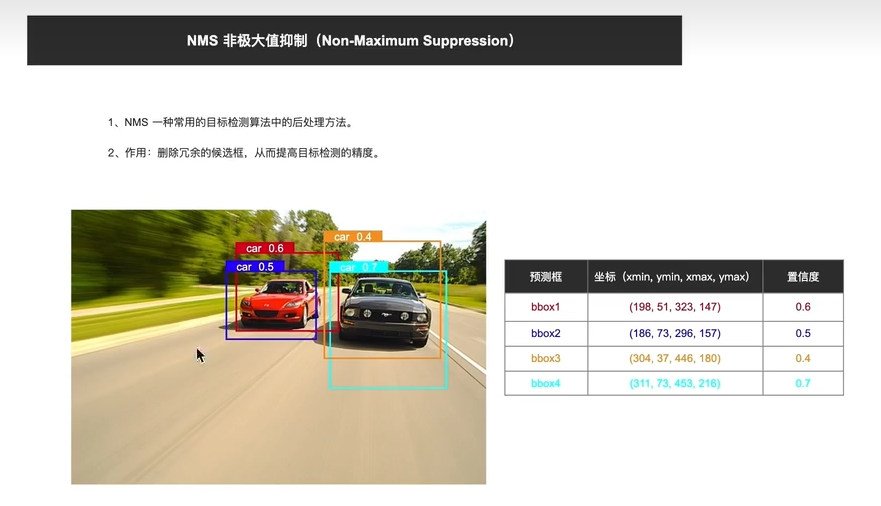

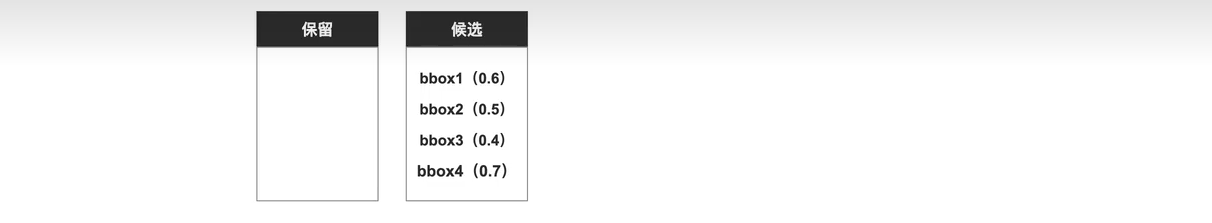
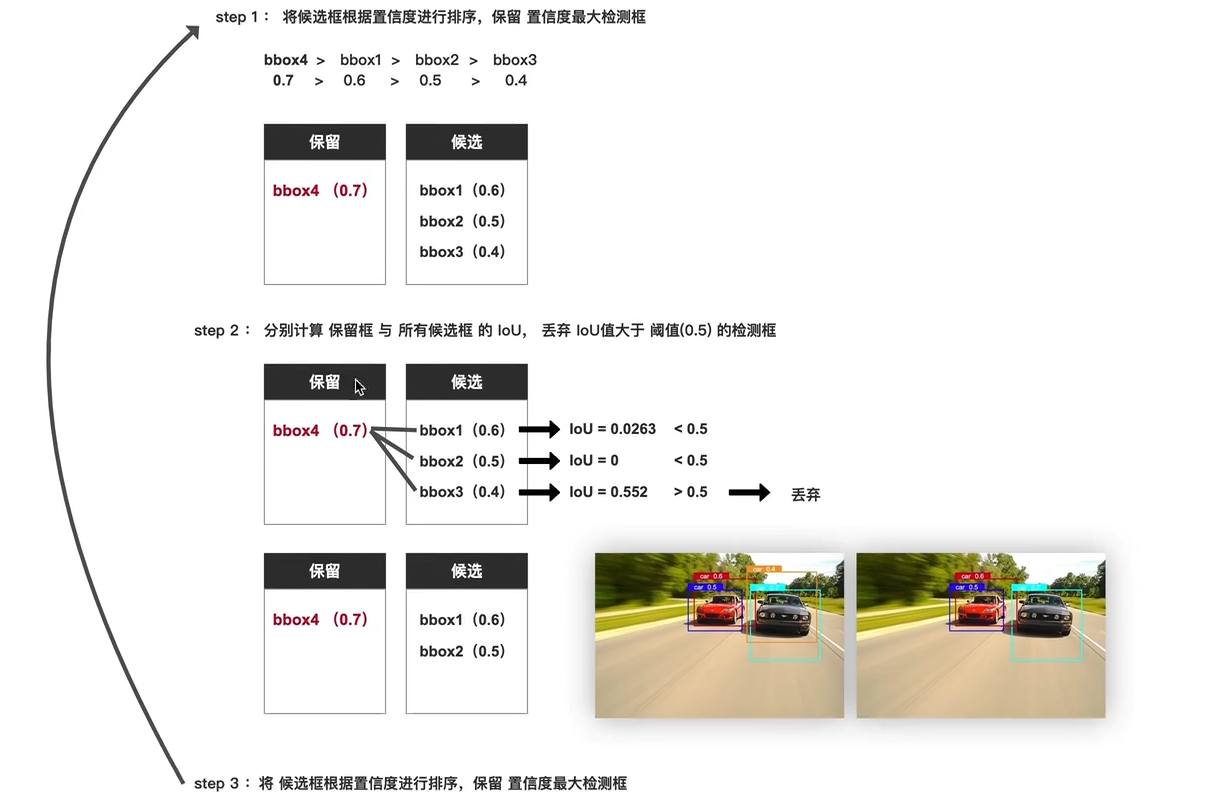
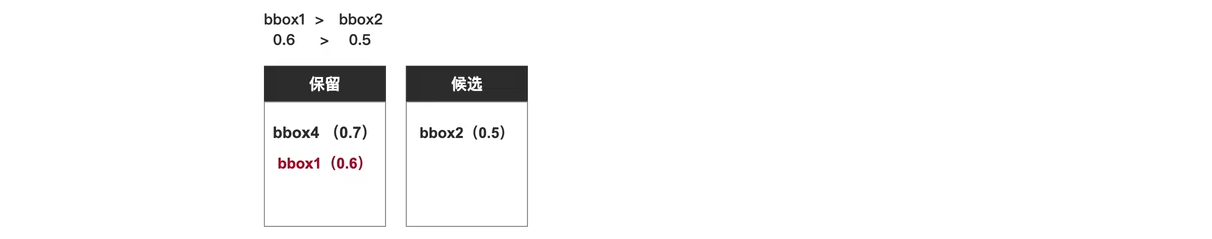
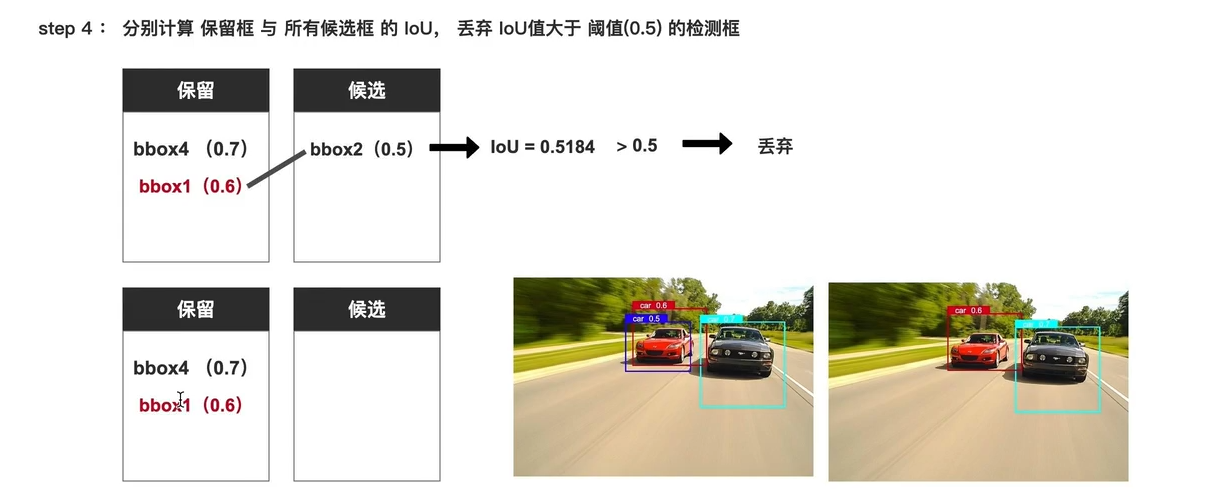

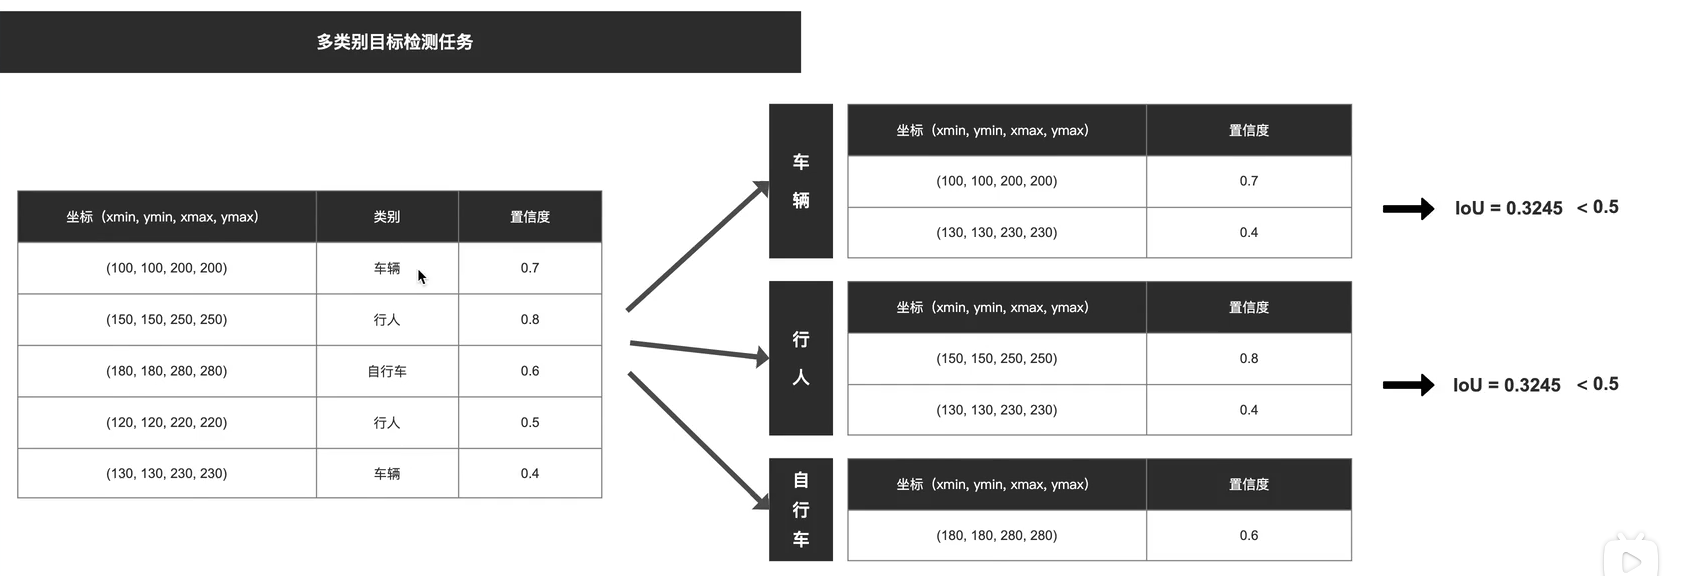

In [ ]:
import torch

def nms_torch(boxes, scores, iou_threshold=0.5):
    """
    boxes: [N, 4] (x1, y1, x2, y2), Tensor
    scores: [N], Tensor
    return: 保留的索引列表 (Tensor)
    """
    # 边界保护：如果没有框，直接返回空
    if boxes.numel() == 0:
        return torch.empty(0, dtype=torch.long, device=boxes.device)
    
    # 1. 按置信度降序排序 (返回的是索引)
    order = torch.argsort(scores, descending=True)
    keep = []  # 存储最终保留下来的索引 (Python list)
    
    while order.numel() > 0:
        # 2. 取出当前最高分框的索引
        idx = order[0]
        keep.append(idx.item())  # 注意：要转成 Python int 存，方便后续处理
        
        # 如果只剩一个框，直接结束
        if order.numel() == 1:
            break
        
        # 3. 计算当前最高分框 与 剩余所有框 的 IoU
        curr_box = boxes[idx]                    # [4]
        rest_boxes = boxes[order[1:]]            # [M, 4] (M = N-1)
        
        # ----- 交集区域 -----
        inter_x1 = torch.maximum(curr_box[0], rest_boxes[:, 0])
        inter_y1 = torch.maximum(curr_box[1], rest_boxes[:, 1])
        inter_x2 = torch.minimum(curr_box[2], rest_boxes[:, 2])
        inter_y2 = torch.minimum(curr_box[3], rest_boxes[:, 3])
        
        inter_w = torch.clamp(inter_x2 - inter_x1, min=0.0)
        inter_h = torch.clamp(inter_y2 - inter_y1, min=0.0)
        inter_area = inter_w * inter_h
        
        # ----- 并集区域 -----
        area1 = (curr_box[2] - curr_box[0]) * (curr_box[3] - curr_box[1])
        area2 = (rest_boxes[:, 2] - rest_boxes[:, 0]) * (rest_boxes[:, 3] - rest_boxes[:, 1])
        union_area = area1 + area2 - inter_area + 1e-6  # 加 eps 防止除零
        
        ious = inter_area / union_area
        
        # 4. 核心逻辑：保留 IoU <= 阈值的框 (这些是与当前框不重叠的)
        #    特别注意：order[1:] 对应 rest_boxes，筛选后赋值给 order
        order = order[1:][ious <= iou_threshold]
    
    # 5. 返回 Tensor 类型的索引，方便后续索引 boxes
    return torch.tensor(keep, device=boxes.device, dtype=torch.long)

In [ ]:
from torchvision.ops import nms

# 一行代码搞定，且自动处理 GPU 加速
keep_indices = nms(boxes, scores, iou_threshold=0.5)